#### *Importing necessary libraries*

In [1225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### *Importing dataset*

In [1226]:
df=pd.read_csv('insurance.csv')

#### *separating data into X (features) and y (target)*

In [1227]:
X=df.drop('charges', axis=1)
y=df[['charges']]

#### *Splitting the data into training (80%) and test (20%) sets*

In [1228]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

#### *Encoding categorical features*

In [1229]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[1,4,5])],remainder='passthrough')
X_train=ct.fit_transform(X_train)
X_test=ct.transform(X_test)

#### *Feature scaling*

In [1230]:
from sklearn.preprocessing import StandardScaler
sc_X=StandardScaler()
sc_y=StandardScaler()
X_train=sc_X.fit_transform(X_train)
X_test=sc_X.transform(X_test)
y_train=sc_y.fit_transform(y_train).ravel()

#### *Recovering the feature column names after encoding*

In [1231]:
feature_names=ct.get_feature_names_out()
X_train=pd.DataFrame(X_train,columns=feature_names)
X_test=pd.DataFrame(X_test,columns=feature_names)

#### *Training the data set on SVR RBF kernel*

In [1232]:
from sklearn.svm import SVR
regressor=SVR(kernel='rbf')
regressor.fit(X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


#### *Making predictions on the X_test dataset*

In [1233]:
y_pred=pd.DataFrame(sc_y.inverse_transform(regressor.predict(
    X_test).reshape(-1,1)), columns=['Predicted'])

#### *Evaluation of Model Predictions Using All Features*

In [1234]:
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_absolute_percentage_error, root_mean_squared_error
)
r2i=(r2_score(y_test,y_pred))
print('R2 Sc : ',r2i)
MAE=(mean_absolute_error(y_test,y_pred))
print('MAE   : ',MAE)
print('MAPE  : ',mean_absolute_percentage_error(y_test,y_pred))
print('RMSE  : ',root_mean_squared_error(y_test,y_pred))
print('MAPEM : ',MAE/np.mean(y_test))

R2 Sc :  0.8869590298175918
MAE   :  2464.325404980602
MAPE  :  0.23423203313127028
RMSE  :  4241.25044367615
MAPEM :  0.18191110292100598


#### *Feature Importance Evaluation Using Permutation Importance*

In [1235]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
regressor, X_test, y_test, n_repeats=20, random_state=42
)

importance = result.importances_mean

#### *Aggregation of Feature Importance by Original Feature*

In [1236]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df["Original_Feature"] = importance_df["Feature"].apply(
    lambda x: x.split("__")[1].split("_")[0] if "encoder" in x else x.split("__")[1]
)

group_importance = importance_df.groupby("Original_Feature")["Importance"].mean()
print(group_importance)

Original_Feature
age         0.000018
bmi         0.000029
children    0.000003
region      0.000001
sex         0.000001
smoker      0.000066
Name: Importance, dtype: float64


#### *Iterative Feature Selection with Best Threshold and Model Retraining*

In [1237]:
# baseline score with all features
best_r2 = r2i
best_threshold = None
best_features = X_train.columns

# early stopping patience
patience = 3
bad_rounds = 0

# sorted thresholds
thresholds = np.sort(group_importance.unique())
print("Initial R2 with all features :", r2i)

for threshold in thresholds:

    # get important groups
    important_groups = group_importance[group_importance > threshold].index

    selected_features = importance_df[
        importance_df["Original_Feature"].isin(important_groups)
    ]["Feature"]

    # skip if no features left
    if len(selected_features) == 0:
        continue

    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]

    # train model
    regressor.fit(X_train_sel, y_train.ravel())

    y_pred=pd.DataFrame(sc_y.inverse_transform(
        regressor.predict(X_test_sel).reshape(-1,1)), columns=['Predicted'])

    r2 = r2_score(y_test, y_pred)

    # check improvement
    if r2 > best_r2:
        best_r2 = r2
        best_threshold = threshold
        best_features = selected_features
        bad_rounds = 0
        

    else:
        bad_rounds += 1
        
    # early stopping
    if bad_rounds >= patience:
        
        break


print("Best Threshold during search :", best_threshold)
print("Best R2 during search        :", best_r2)
print("Selected Features            :", len(best_features))

# Retrain final model

X_train_final = X_train[best_features]
X_test_final = X_test[best_features]

regressor.fit(X_train_final, y_train.ravel())

y_pred_final=pd.DataFrame(sc_y.inverse_transform(
    regressor.predict(X_test_final).reshape(-1,1)), columns=['Predicted'])

final_r2 = r2_score(y_test, y_pred_final)

Initial R2 with all features : 0.8869590298175918
Best Threshold during search : 1.4024459322581338e-06
Best R2 during search        : 0.8947875654999831
Selected Features            : 5


#### *Evaluation of Model Predictions Using Selected Features*

In [1238]:
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_absolute_percentage_error, root_mean_squared_error
)
print('R2 Sc Final : ',final_r2)
MAE=(mean_absolute_error(y_test,y_pred_final))
print('MAE Final   : ',MAE)
print('MAPE Final  : ',mean_absolute_percentage_error(y_test,y_pred_final))
print('RMSE Final  : ',root_mean_squared_error(y_test,y_pred_final))
print('MAPEM Final : ',MAE/np.mean(y_test))

R2 Sc Final :  0.8947875654999831
MAE Final   :  2030.5801494748714
MAPE Final  :  0.18183066599933614
RMSE Final  :  4091.7539928259134
MAPEM Final :  0.14989297834365453


#### *Visualization of Predictions vs Actuals*

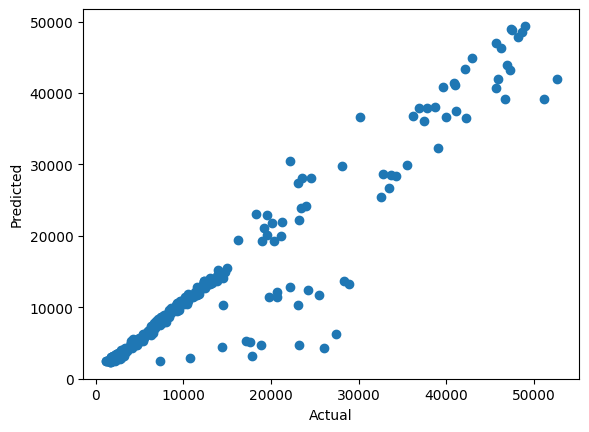

In [1239]:
plt.scatter(y_test, y_pred_final)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

#### *Concanating Actual and Predicted Values*

In [1240]:
y_test=y_test.reset_index(drop=True)
y_test.columns=['Actual']
y_pred_final=y_pred_final.reset_index(drop=True)
pre_con=pd.concat([y_test,y_pred_final], axis=1)
pre_con.head(5)

,Actual,Predicted
0,9724.53000,10943.972625
1,8547.69130,9207.434243
2,45702.02235,46963.546275
3,12950.07120,13627.144794
4,9644.25250,10397.037262
